# Project Conversion rate Challenge

## Imports

In [193]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score
)

## Load Data

In [154]:
train = pd.read_csv("C:/Users/mickt/Downloads/conversion_data_train.csv")
test = pd.read_csv("C:/Users/mickt/Downloads/conversion_data_test.csv")

In [ ]:
train.head()

,country,age,new_user,source,total_pages_visited
0,UK,28,0,Seo,16
1,UK,22,1,Direct,5
2,China,32,1,Seo,1
3,US,32,1,Ads,6
4,China,25,0,Seo,3


In [156]:
test.head()

,country,age,new_user,source,total_pages_visited
0,UK,28,0,Seo,16
1,UK,22,1,Direct,5
2,China,32,1,Seo,1
3,US,32,1,Ads,6
4,China,25,0,Seo,3


In [158]:
print("Train shape:", train.shape)

Train shape: (284580, 6)


In [159]:
print("Test shape:", test.shape)

Test shape: (31620, 5)


### Missing Values Check

In [157]:
train.isna().sum()

country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

## Exploratory Data Analysis (EDA)

### Distribution of Users by Country

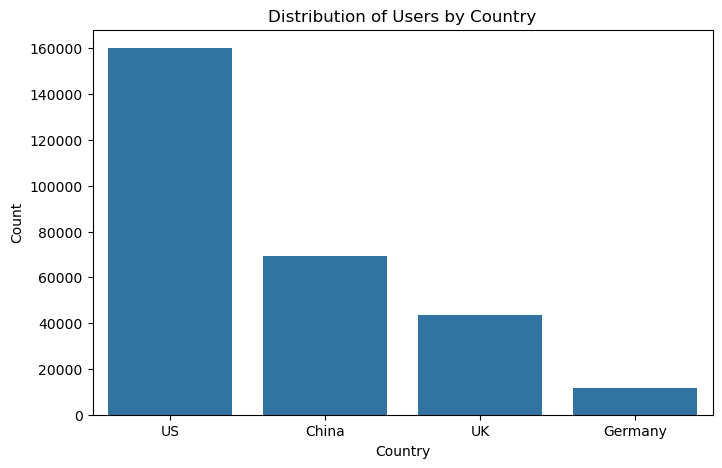

In [160]:
plt.figure(figsize=(8,5))
sns.countplot(x="country", data=train, order=train["country"].value_counts().index)
plt.title("Distribution of Users by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

### Average Pages Visited by Country

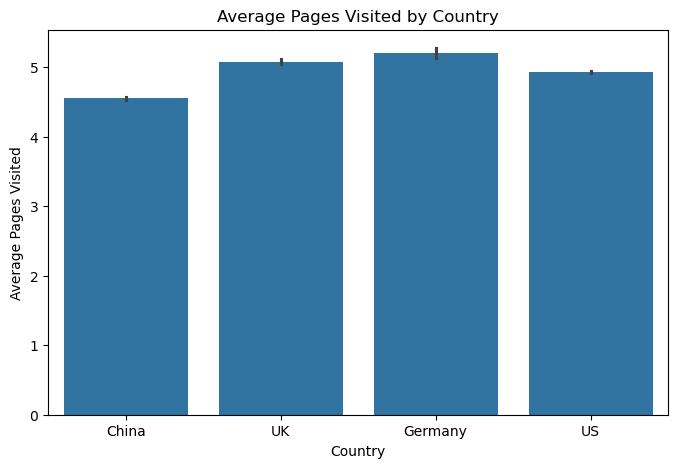

In [161]:
plt.figure(figsize=(8,5))
sns.barplot(x="country", y="total_pages_visited", data=train)
plt.title("Average Pages Visited by Country")
plt.xlabel("Country")
plt.ylabel("Average Pages Visited")
plt.show()


### Age Distribution by Country

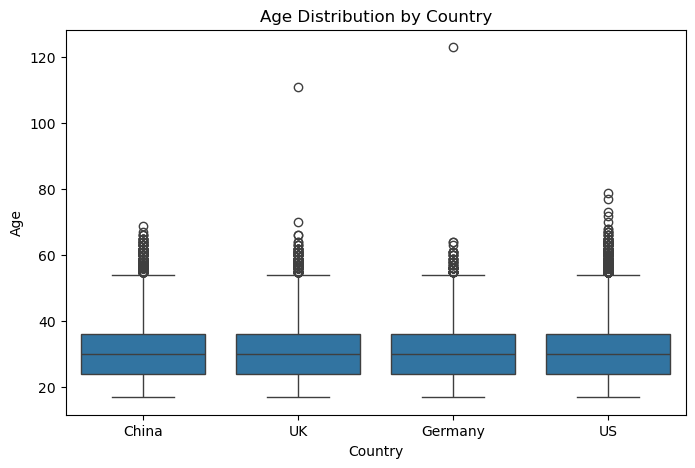

In [162]:
plt.figure(figsize=(8,5))
sns.boxplot(x="country", y="age", data=train)
plt.title("Age Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Age")
plt.show()

### Distribution of User Type

C:\Users\mickt\AppData\Local\Temp\ipykernel_19460\166451289.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Returning User", "New User"])


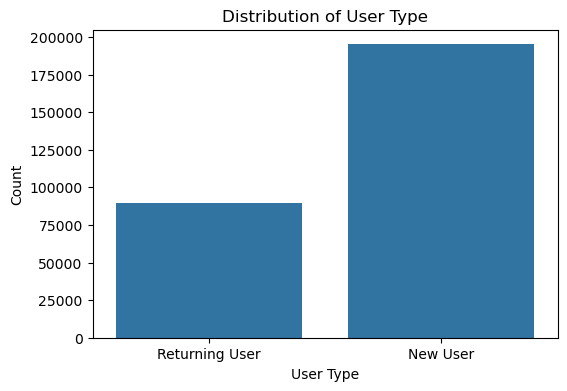

In [163]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="new_user", data=train)
ax.set_xticklabels(["Returning User", "New User"])
plt.title("Distribution of User Type")
plt.xlabel("User Type")
plt.ylabel("Count")
plt.show()

### Source Distribution Among New Users

In [164]:
new_users_by_source = train[train["new_user"] == 1]["source"].value_counts()

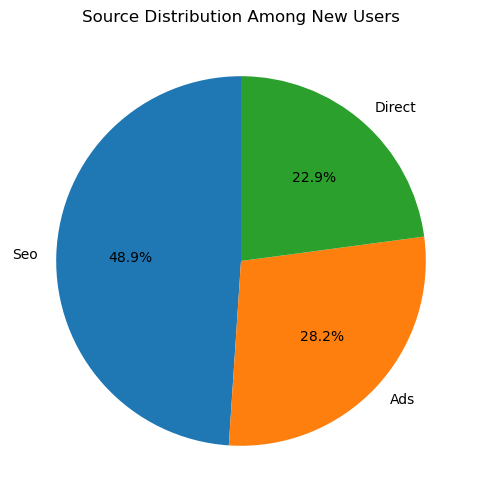

In [170]:
plt.figure(figsize=(6,6))
plt.pie(
    new_users_by_source,
    labels=new_users_by_source.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Source Distribution Among New Users")
plt.show()

### Conversion Distribution

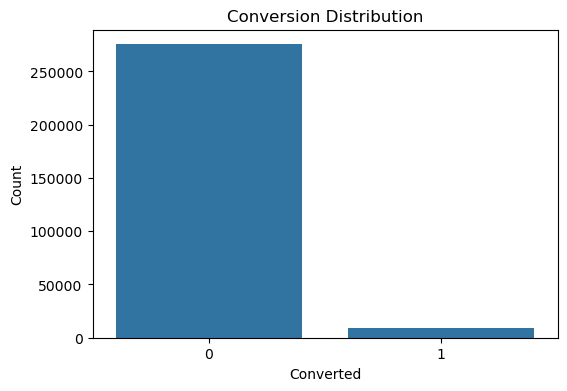

In [171]:
plt.figure(figsize=(6,4))
sns.countplot(x="converted", data=train)
plt.title("Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Count")
plt.show()

### Average Pages Visited by Conversion

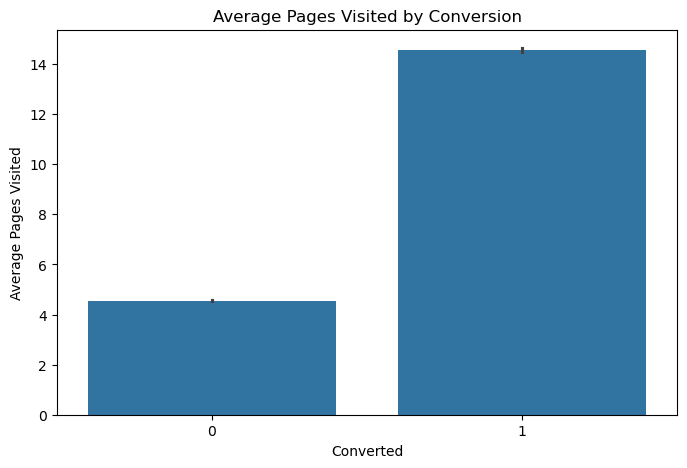

In [172]:
plt.figure(figsize=(8,5))
sns.barplot(x="converted", y="total_pages_visited", data=train)
plt.title("Average Pages Visited by Conversion")
plt.xlabel("Converted")
plt.ylabel("Average Pages Visited")
plt.show()

## Preprocessing

In [173]:
train_encoded = pd.get_dummies(train, columns=["country", "source"], drop_first=True)

In [174]:
X = train_encoded.drop("converted", axis=1)
y = train_encoded["converted"]

### Train / Validation Split

In [175]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Baseline Logistic Regression

In [176]:
baseline_model = LogisticRegression()
baseline_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [177]:
y_pred = baseline_model.predict(X_valid)
y_proba = baseline_model.predict_proba(X_valid)[:, 1]

## Baseline Model Evaluation

In [178]:
print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))
print("ROC AUC:", roc_auc_score(y_valid, y_proba))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55058
           1       0.85      0.69      0.76      1858

    accuracy                           0.99     56916
   macro avg       0.92      0.85      0.88     56916
weighted avg       0.99      0.99      0.99     56916

[[54825   233]
 [  567  1291]]
ROC AUC: 0.9872129560915917


### ROC Curve

In [179]:
fpr, tpr, thresholds = roc_curve(y_valid, y_proba)

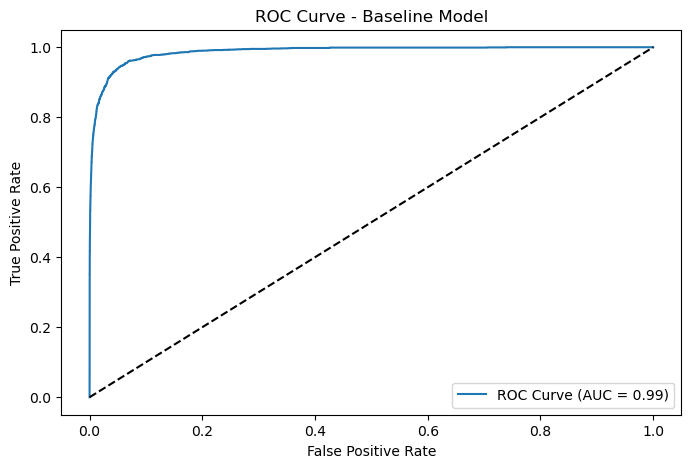

In [180]:
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_valid, y_proba):.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Model")
plt.legend(loc="lower right")
plt.show()


## Gradient Boosting (main improvement model)  

In [201]:
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [202]:
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [203]:
y_proba_gb = gb_model.predict_proba(X_valid)[:, 1]
y_pred_gb = (y_proba_gb > 0.5).astype(int)

In [204]:
print(classification_report(y_valid, y_pred_gb))
print(confusion_matrix(y_valid, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_valid, y_proba_gb))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55058
           1       0.85      0.69      0.76      1858

    accuracy                           0.99     56916
   macro avg       0.92      0.84      0.88     56916
weighted avg       0.99      0.99      0.99     56916

[[54828   230]
 [  573  1285]]
ROC AUC: 0.9872356985241632


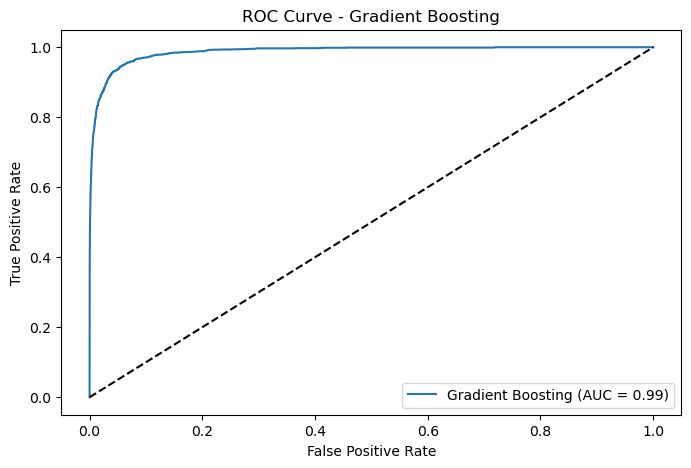

In [205]:
fpr, tpr, thresholds = roc_curve(y_valid, y_proba_gb)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {roc_auc_score(y_valid, y_proba_gb):.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend(loc="lower right")
plt.show()

In [206]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_proba_gb > t).astype(int)
    print(f"Threshold {t}: F1 = {f1_score(y_valid, y_pred):.4f}")

Threshold 0.3: F1 = 0.7626
Threshold 0.4: F1 = 0.7717
Threshold 0.5: F1 = 0.7619
Threshold 0.6: F1 = 0.7437
Threshold 0.7: F1 = 0.7242


In [207]:
y_test_proba_gb = gb_model.predict_proba(X_test)[:, 1]
y_test_pred_gb = (y_test_proba_gb > 0.4).astype(int)

In [ ]:
submission = pd.DataFrame({
    "converted": y_test_pred_gb
})

submission.to_csv(
    "submission_gradient_boosting.csv",
    index=False
)

## Hyperparameter Tuning


In [181]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

In [182]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc"
)

In [183]:
grid_search.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [ ]:
print("Best parameters found:", grid_search.best_params_)

### Best Tuned Model

In [184]:
best_model = grid_search.best_estimator_

In [185]:
y_proba_best = best_model.predict_proba(X_valid)[:, 1]
y_pred_best = (y_proba_best > 0.4).astype(int)

### Tuned Model Evaluation

In [186]:
print(classification_report(y_valid, y_pred_best))
print(confusion_matrix(y_valid, y_pred_best))
print("ROC AUC:", roc_auc_score(y_valid, y_proba_best))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     55058
           1       0.81      0.74      0.77      1858

    accuracy                           0.99     56916
   macro avg       0.90      0.87      0.88     56916
weighted avg       0.99      0.99      0.99     56916

[[54737   321]
 [  489  1369]]
ROC AUC: 0.9872077262607616


### Threshold Optimization

In [187]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_proba_best > t).astype(int)
    print(f"Threshold {t}: F1 = {f1_score(y_valid, y_pred):.4f}")

Threshold 0.3: F1 = 0.7620
Threshold 0.4: F1 = 0.7717
Threshold 0.5: F1 = 0.7629
Threshold 0.6: F1 = 0.7442
Threshold 0.7: F1 = 0.7137


## Prepare Competition Test Set

In [188]:
X_test = test.copy()
X_test = pd.get_dummies(X_test)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

### Generate Test Predictions

In [189]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba > 0.4).astype(int)

### Create Submission File

In [191]:
submission = pd.DataFrame({"converted": y_test_pred})
submission.to_csv(
    "C:/me/Projects/Aggregate/Project_supervised_Conversion_rate_challenge/submission.csv",
    index=False
)

In [190]:
submission["converted"].value_counts()

converted
0    30704
1      916
Name: count, dtype: int64

### Save Final Model

In [192]:
joblib.dump(
    best_model,
    "C:/me/Projects/Aggregate/Project_supervised_Conversion_rate_challenge/best_model.pkl"
)

['C:/me/Projects/Aggregate/Project_supervised_Conversion_rate_challenge/best_model.pkl']

# Conclusion

### Final Conclusion

#### The Logistic Regression model achieved strong overall performance, with an F1-score around 0.77 on the minority class after threshold optimization.
#### The strongest predictive signal comes from user engagement, especially the number of pages visited.
#### While hyperparameter tuning had limited impact, threshold tuning improved the balance between precision and recall.
#### Further gains are likely to come from better feature engineering, class imbalance handling, or non-linear models.